[1942.307, 1945.814, 1946.305, 1956.31, 1965.635, 1945.895, 1961.124, 1952.515, 1936.612, 1938.003, 1942.801, 1966.547, 1918.432, 1922.684, 1956.824, 1922.333, 1934.019, 1933.14, 1932.288, 1928.098, 1930.494, 1931.609, 1930.387, 1952.931, 1919.583, 1947.719, 1934.37, 1928.504, 1921.989, 1956.482, 1950.464, 1915.225, 1938.85, 1942.602, 1912.667, 1934.745, 1939.995, 1919.962, 1959.661, 1912.863]


(array([3., 6., 2., 6., 5., 4., 4., 3., 5., 2.]),
 array([1912.667, 1918.055, 1923.443, 1928.831, 1934.219, 1939.607,
        1944.995, 1950.383, 1955.771, 1961.159, 1966.547]),
 <BarContainer object of 10 artists>)

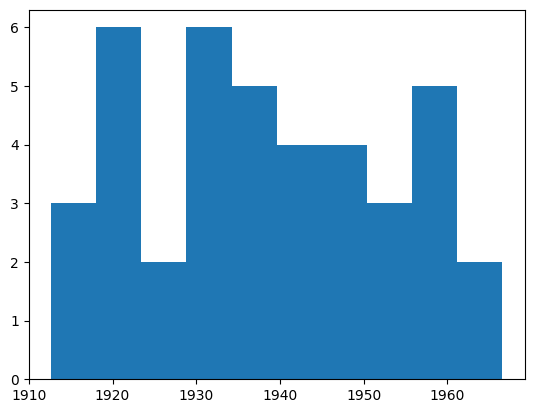

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math


prefix = "../results/"
instance = "pg_duckdb_parquet"
postfix = "_01_big_query.dat"
f = prefix + instance + postfix

t = []
with open(f, 'r') as file:
    for line in file:
        clear = line.strip()
        if clear:
            clear_dot = clear.replace(',', '.')
            t.append(float(clear_dot))
print(t)
plt.hist(t)

In [2]:
test_normal = stats.normaltest(t)
test_shapiro = stats.shapiro(t)
# print(test_normal, test_shapiro, sep = '\n')
print("Тест на нормальность данных: ", end='')
if test_normal[1] > 0.05 or test_shapiro[1] > 0.05:
    print("ПРОЙДЕН")
else:
    print("НЕ ПРОЙДЕН")

Тест на нормальность данных: ПРОЙДЕН


In [3]:
mean = np.mean(t)
std = np.std(t, ddof=1)
quality = (std / mean) * 100
print(f"Среднее: {mean}\nСтандартное отклонение: {std}\nОтношение std/mean (%): {quality}")

Среднее: 1938.2197
Стандартное отклонение: 14.82583319784277
Отношение std/mean (%): 0.7649201583206884


In [4]:
interval = stats.t.ppf(0.975, df=len(t)-1)*stats.sem(t)
print(f"Доверительный интервал: {interval}")

Доверительный интервал: 4.741531486779593


### Округление
- Погрешность: 5 (мс)
- Среднее: 1938 (мс)
### Итог
- Результирующее значение: 1938 ± 5 (мс)